In [12]:
%pip install --target=/storage1/fs1/jmillman/Active/DigitalTwin/python-packages tables
%pip install --target=/storage1/fs1/jmillman/Active/DigitalTwin/python-packages ipywidgets
import sys
sys.path.append('/storage1/fs1/jmillman/Active/DigitalTwin/python-packages')

  Using cached tables-3.8.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.2 kB)
  Using cached cython-3.2.4-cp38-cp38-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (7.3 kB)
  Using cached numpy-1.24.4-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached numexpr-2.8.6-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.0 kB)
  Using cached blosc2-2.0.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached py_cpuinfo-9.0.0-py3-none-any.whl.metadata (794 bytes)
  Using cached msgpack-1.1.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.3 kB)
Using cached tables-3.8.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (6.5 MB)
Using cached blosc2-2.0.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.9 MB)
Using cached cython-3.2.4-cp38-cp38-many

In [13]:
import copy
import glob
import importlib
import time
import os
import shutil
import sys
from importlib import reload

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from tqdm.notebook import tqdm

import ipywidgets

#import time

os.chdir("/storage1/fs1/jmillman/Active/DigitalTwin")


In [14]:
import celloracle as co
from celloracle.applications import Oracle_development_module
co.__version__

'0.18.0'

In [15]:
#plt.rcParams["font.family"] = "arial"
plt.rcParams["figure.figsize"] = [5,5]
%config InlineBackend.figure_format = 'retina'
plt.rcParams["savefig.dpi"] = 300

%matplotlib inline

In [16]:
#Import objects
oracle = co.load_hdf5("checkpoints/celloracle/DT_Subset_Delta.celloracle.oracle")
links = co.load_hdf5("checkpoints/celloracle/DT_Subset_Delta.celloracle.links")


In [17]:
#Import gradient
gradient = co.load_hdf5("checkpoints/gradient_DT_Subset_Delta.celloracle.gradient")

# Please make sure that the number of cells and dimensional reduction data 
#is exact same between oracle object and gradient object
print(oracle.adata.shape, gradient.embedding.shape)

assert((oracle.adata.obsm[oracle.embedding_name] == gradient.embedding).all())

(7583, 3123) (7583, 2)


In [18]:
links.filter_links()
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)
oracle.fit_GRN_for_simulation(alpha=10, use_cluster_specific_TFdict=True)

  0%|          | 0/4 [00:00<?, ?it/s]

In [19]:
# You can get the list of genes that have at least one regulatory connection in the inferred GRNs.
genes = oracle.active_regulatory_genes
len(genes)

220

In [20]:
# List of cluster name
sorted(list(oracle.adata.obs["celltype_Delta_subset"].unique()))

['Delta', 'EP', 'PP', 'eDelta']

In [21]:
# Get cell_id
clusters_end_lineage = np.where(oracle.adata.obs["celltype_Delta_subset"].isin(['PP', "EP", 'eDelta','Delta']))[0]
clusters_PP_lineage = np.where(oracle.adata.obs["celltype_Delta_subset"].isin(["PP"]))[0]
clusters_EP_lineage = np.where(oracle.adata.obs["celltype_Delta_subset"].isin(["EP"]))[0]
clusters_Delta_lineage = np.where(oracle.adata.obs["celltype_Delta_subset"].isin(['Delta']))[0]
clusters_eDelta_lineage = np.where(oracle.adata.obs["celltype_Delta_subset"].isin(['eDelta']))[0]

# Make a dictionary
index_dictionary = {"Endocrine": clusters_end_lineage,
                    "PP": clusters_PP_lineage,
                    "EP": clusters_EP_lineage,
                    "Delta": clusters_Delta_lineage,
                    "eDelta": clusters_eDelta_lineage}
                    
index_dictionary

{'Endocrine': array([   0,    1,    2, ..., 7580, 7581, 7582]),
 'PP': array([   0,    1,    8, ..., 7576, 7579, 7580]),
 'EP': array([   5,    9,   16, ..., 7578, 7581, 7582]),
 'Delta': array([   2,    3,    4, ..., 7554, 7555, 7567]),
 'eDelta': array([  33,   38,   42,   58,   59,  129,  143,  145,  156,  173,  185,
         190,  210,  221,  229,  230,  244,  247,  251,  252,  262,  269,
         270,  272,  290,  309,  321,  343,  344,  349,  352,  364,  372,
         374,  376,  387,  388,  392,  410,  450,  453,  467,  487,  492,
         496,  533,  539,  541,  548,  549,  558,  584,  586,  588,  593,
         620,  646,  659,  669,  676,  682,  708,  724,  729,  732,  749,
         784,  801,  805,  809,  817,  819,  834,  850,  851,  867,  885,
         895,  910,  925,  930,  935,  939,  951,  976,  978,  980,  988,
         996, 1016, 1021, 1024, 1027, 1029, 1041, 1051, 1053, 1055, 1060,
        1065, 1076, 1082, 1083, 1090, 1092, 1093, 1111, 1133, 1156, 1197,
        1206

In [22]:
n_propagation = 3
n_neighbors=200

file_path = "checkpoints/DT_Subset_Delta.celloracle.hdf5" 
# Please use .hdf5 for extension.

In [23]:
# 0. Define parameters
def pipeline(gene_for_KO):
     
    # 1. Simulate KO
    oracle.simulate_shift(perturb_condition={gene_for_KO: 0},
                                 ignore_warning=True,
                                 n_propagation=3)
    oracle.estimate_transition_prob(n_neighbors=n_neighbors, knn_random=True, 
                                    sampled_fraction=1)
    oracle.calculate_embedding_shift(sigma_corr=0.05)

    # Do simulation for all conditions.
    for lineage_name, cell_idx in index_dictionary.items():
        
        dev = Oracle_development_module()
        # Load development flow
        dev.load_differentiation_reference_data(gradient_object=gradient)
        # Load simulation result
        dev.load_perturb_simulation_data(oracle_object=oracle, 
                                         cell_idx_use=cell_idx, 
                                         name=lineage_name)
        # Calculate inner product
        dev.calculate_inner_product()
        dev.calculate_digitized_ip(n_bins=10)
        
        # Save results in a hdf5 file.
        dev.set_hdf_path(path=file_path) 
        dev.dump_hdf5(gene=gene_for_KO, misc=lineage_name)

In [24]:
# You can get the list of genes that have at least one regulatory connection in the inferred GRNs.
genes = oracle.active_regulatory_genes #All TFs available
len(genes)

220

# Run only the first time

In [14]:
%%time

#Test only 1 gene
#pipeline(gene_for_KO="ARID2")

# Test pipeline with some genes
test_genes =  genes

for gene in tqdm(test_genes):
    pipeline(gene_for_KO=gene)


  0%|          | 0/220 [00:00<?, ?it/s]

No hdf file found in the path. New hdf5 file was created.
CPU times: user 1d 1h 30min 43s, sys: 29min 8s, total: 1d 1h 59min 52s
Wall time: 2h 48min 23s


2026-03-30 16:12:33,662 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-30 16:12:33,667 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


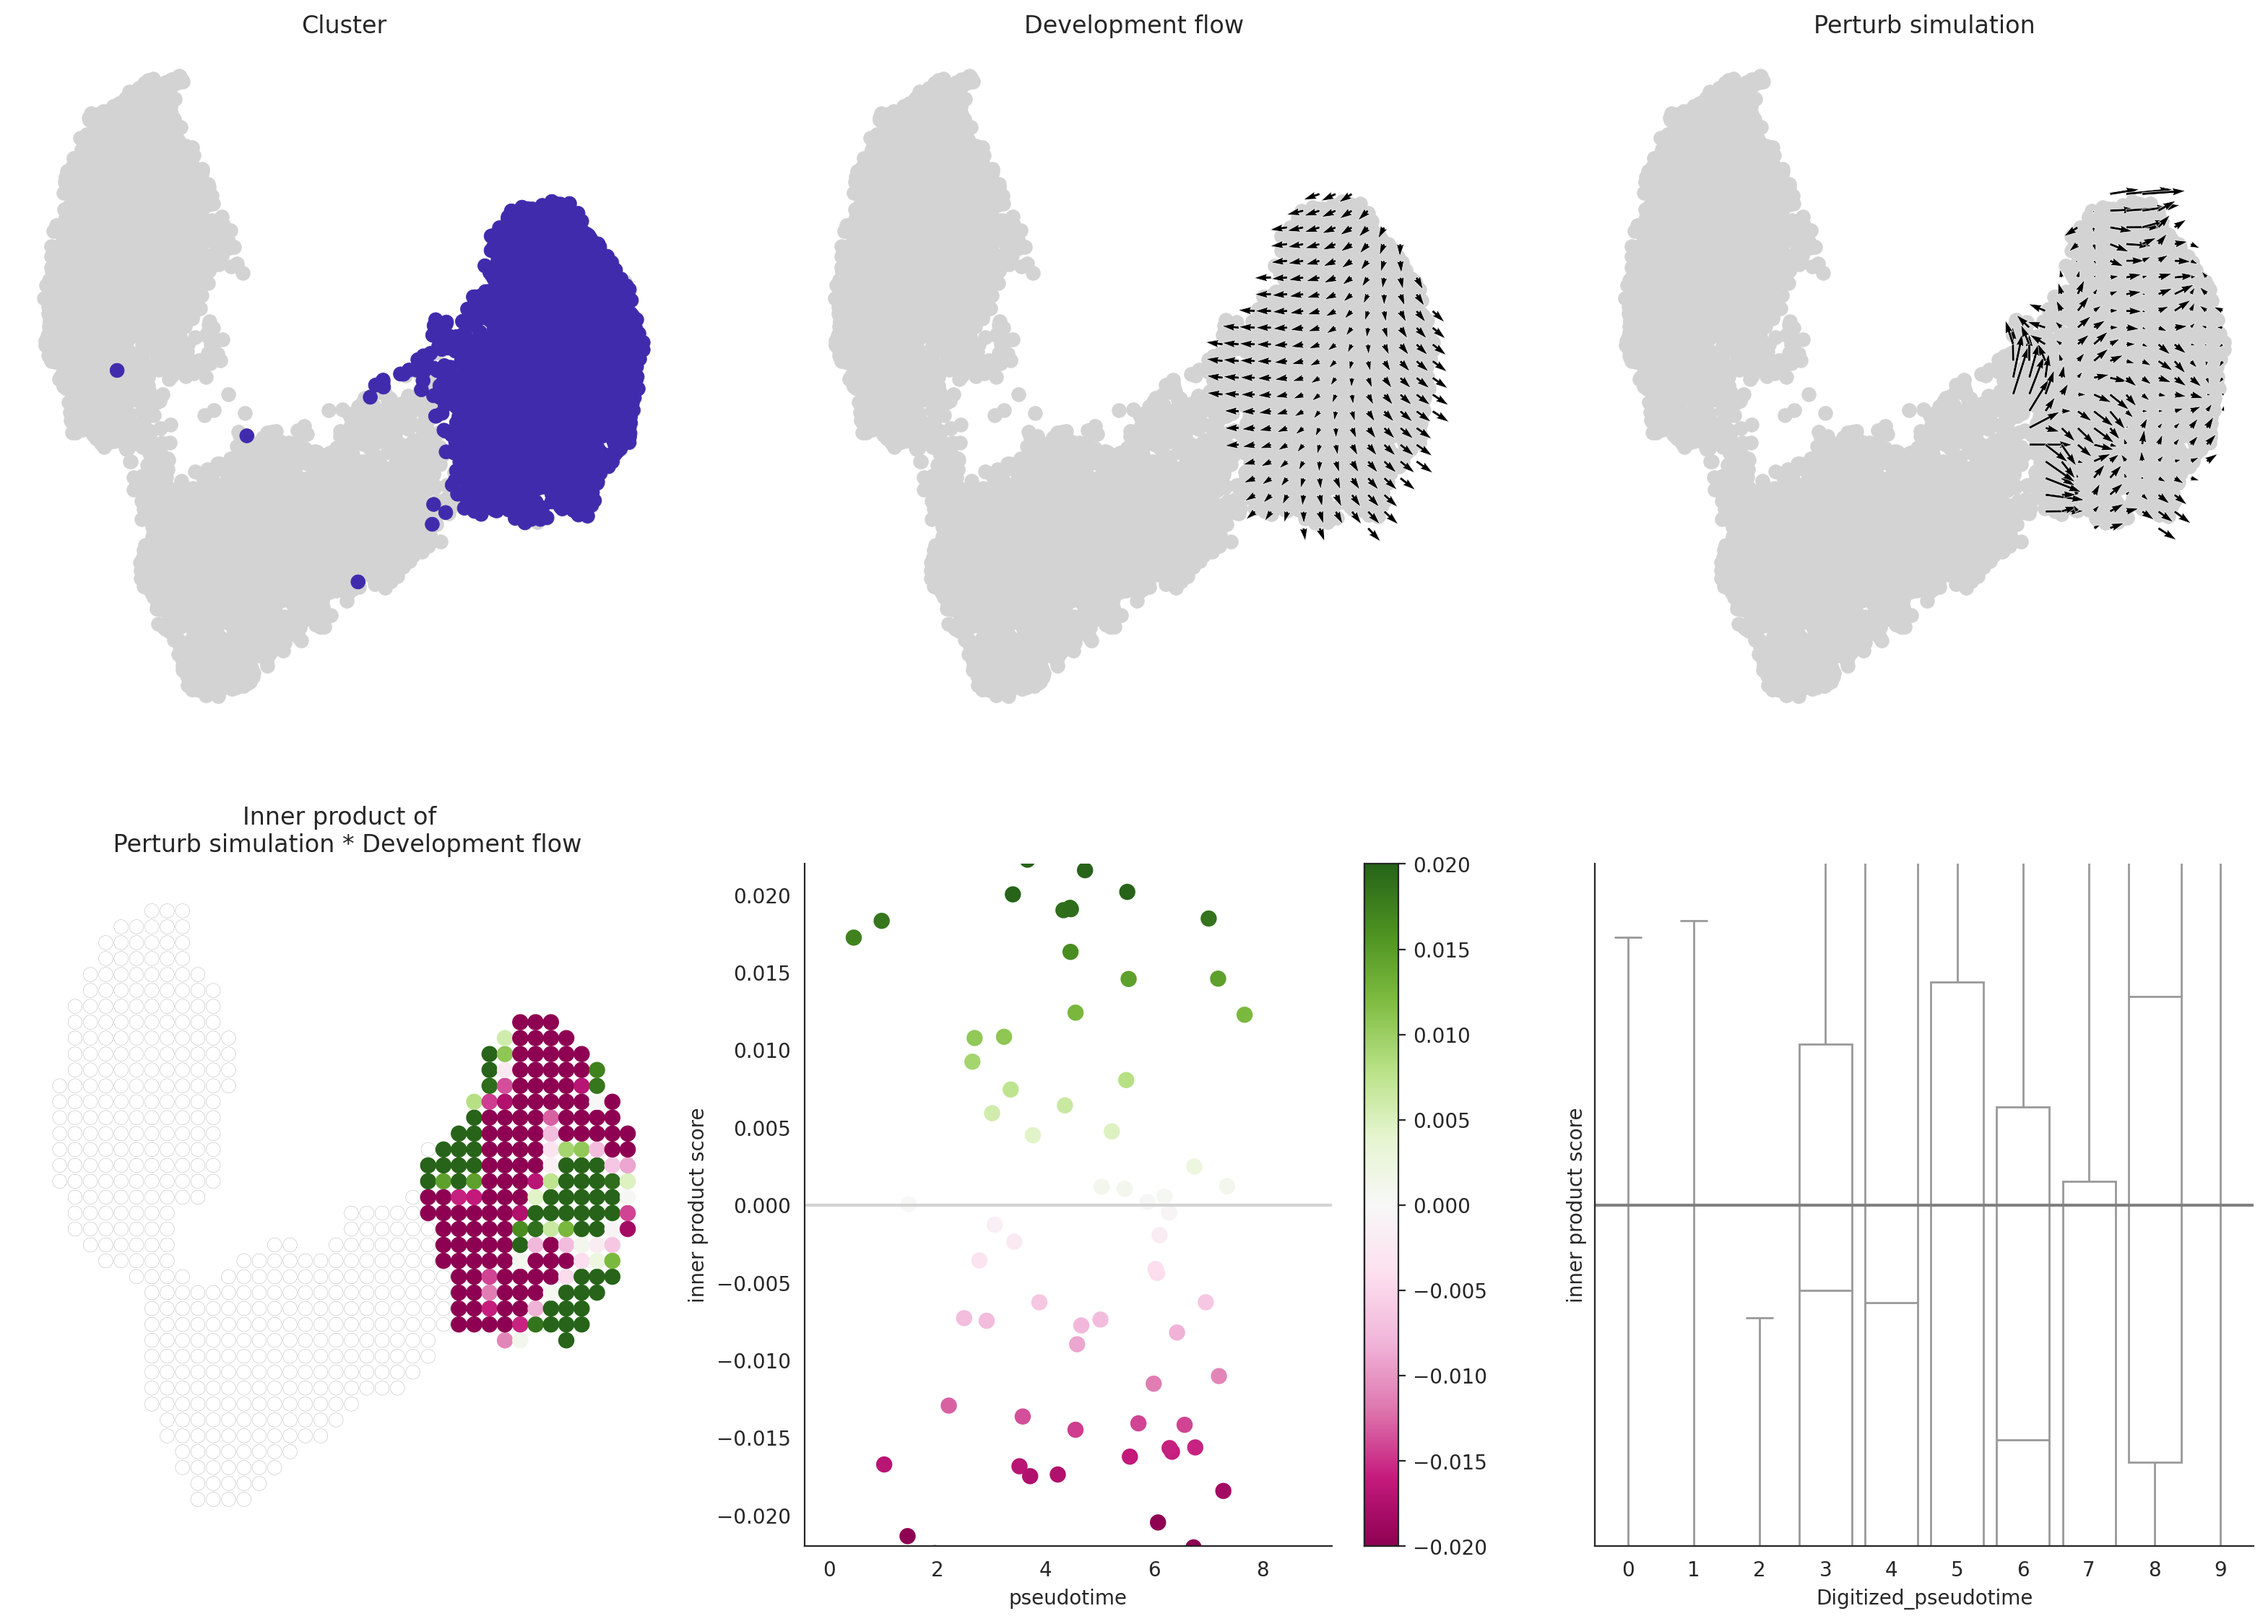

In [15]:
# Make a new Oracle_developmennt_module object to read calculation result
dev_test = Oracle_development_module()

# Read result
dev_test.set_hdf_path(path=file_path)
dev_test.load_hdf5(gene="ZEB1", misc="PP")

# Visualize result
dev_test.visualize_development_module_layout_0(s=50, scale_for_simulation=4, s_grid=50,
                                          scale_for_pseudotime=40, vm=0.02)

In [16]:
# Make Oracle development module class to load data
file_path = "checkpoints/DT_Subset_Delta.celloracle.hdf5" 
dev = Oracle_development_module()
dev.set_hdf_path(path=file_path)

In [17]:
# If we use the function below, we can see information of the saved data
info = dev.get_hdf5_info()

print("Genes\n", info["gene_list"])

print("\nSimulation conditions\n", info["misc_list"])

Genes
 ['AFP' 'AHR' 'ALX1' 'AR' 'ARHGEF12' 'ARID2' 'ARID5B' 'ARNT2' 'ARX' 'ASCL1'
 'ASCL2' 'ATF2' 'ATF6' 'BACH1' 'BACH2' 'BBX' 'BCL11A' 'BCLAF1' 'BDP1'
 'BPTF' 'CBX5' 'CCDC6' 'CDX2' 'CHD2' 'CLOCK' 'CREB1' 'CREB3L2' 'CREB5'
 'CTCF' 'CUX1' 'CUX2' 'E2F3' 'E2F7' 'EBF1' 'EBF3' 'EGR1' 'ELF1' 'ELF2'
 'ENO1' 'EPAS1' 'ESR1' 'ESR2' 'ESRRB' 'ESRRG' 'ETS1' 'ETS2' 'ETV1' 'ETV6'
 'FEV' 'FOS' 'FOXA1' 'FOXA2' 'FOXA3' 'FOXC1' 'FOXJ1' 'FOXJ3' 'FOXN2'
 'FOXN3' 'FOXO1' 'FOXO3' 'FOXP1' 'FOXP2' 'GATA4' 'GLI2' 'GLI3' 'GLIS3'
 'GRHL2' 'GTF2I' 'HDAC2' 'HES1' 'HESX1' 'HEY1' 'HIF1A' 'HIVEP1' 'HIVEP2'
 'HIVEP3' 'HLTF' 'HMGA1' 'HMGA2' 'HMGN3' 'HNF1A' 'HNF1B' 'HNF4A' 'HNF4G'
 'HOXB2' 'ID1' 'ID2' 'ID3' 'ID4' 'IKZF2' 'INSM1' 'IRX1' 'IRX2' 'ISL1'
 'ISX' 'JUN' 'JUND' 'KLF12' 'KLF2' 'KLF5' 'KLF7' 'LHX1' 'LHX4' 'LMO2'
 'LMX1A' 'LMX1B' 'MAF' 'MAFB' 'MECOM' 'MEF2A' 'MEF2C' 'MEIS1' 'MEIS2'
 'MITF' 'MLXIPL' 'MXI1' 'MYCN' 'MYEF2' 'NEUROD1' 'NEUROD4' 'NEUROG3' 'NF1'
 'NFAT5' 'NFATC2' 'NFATC3' 'NFIA' 'NFIB' 'NFKB1' 'NKX2-2' 'NK

# Load object with all the simulations

In [25]:
import h5py

In [26]:
# Open the HDF5 file in read-only mode
with h5py.File(file_path, 'r') as file:
    # Define the list of groups and subgroups
    groups = genes

    
    subgroups = ['PP', "EP", 'eDelta','Delta']

    # Create a dictionary to store the average inner product values
    average_values = {'Group': [], 'Subgroup': [], 'Average Inner Product': []}

    # Iterate through groups and subgroups
    for group in groups:
        for subgroup in subgroups:
            # Construct the dataset path
            dataset_path = f'{group}/{subgroup}/inner_product'

            # Check if the dataset exists
            if dataset_path in file:
                # Access the inner_product dataset
                inner_product_data = file[dataset_path][()]

                # Calculate the average inner product value
                average_value = inner_product_data.mean()

                # Store the results in the dictionary
                average_values['Group'].append(group)
                average_values['Subgroup'].append(subgroup)
                average_values['Average Inner Product'].append(average_value)

# Create a DataFrame from the dictionary
df = pd.DataFrame(average_values)

# Display the DataFrame
print(df)

      Group Subgroup  Average Inner Product
0       AFP       PP               0.000749
1       AFP       EP              -0.002161
2       AFP   eDelta              -0.000934
3       AFP    Delta               0.002671
4       AHR       PP              -0.003826
..      ...      ...                    ...
875  ZNF652    Delta               0.004743
876  ZNF708       PP              -0.010087
877  ZNF708       EP              -0.003736
878  ZNF708   eDelta              -0.003500
879  ZNF708    Delta               0.003724

[880 rows x 3 columns]


In [27]:
import pandas as pd

# Make a table with one row per TF KO and one column per cell state
ps_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Optional: sort TFs alphabetically
ps_table = ps_table.sort_index()

# Optional: remove the column/index names for cleaner export
ps_table.index.name = 'TF_KO'
ps_table.columns.name = None

# Preview
print(ps_table)

# Save as CSV
ps_table.to_csv("outputs/celloracle_tables/DT_Subset_Delta/PS_scores_per_TFKO_per_cellstate.csv")
# Table S19

             Delta        EP        PP    eDelta
TF_KO                                           
AFP       0.002671 -0.002161  0.000749 -0.000934
AHR      -0.003122  0.004578 -0.003826 -0.003521
ALX1      0.000539  0.000820  0.001360  0.000530
AR       -0.000208  0.002045  0.001900  0.001053
ARHGEF12 -0.000287  0.006111 -0.001572 -0.000275
...            ...       ...       ...       ...
ZNF148    0.004769 -0.005766  0.000878 -0.006827
ZNF423    0.007503  0.003257  0.010439  0.000284
ZNF431   -0.002964 -0.001005 -0.003400 -0.001360
ZNF652    0.004743  0.001960 -0.000696  0.001905
ZNF708    0.003724 -0.003736 -0.010087 -0.003500

[220 rows x 4 columns]


# Plotting #Fig. S21H and S21I

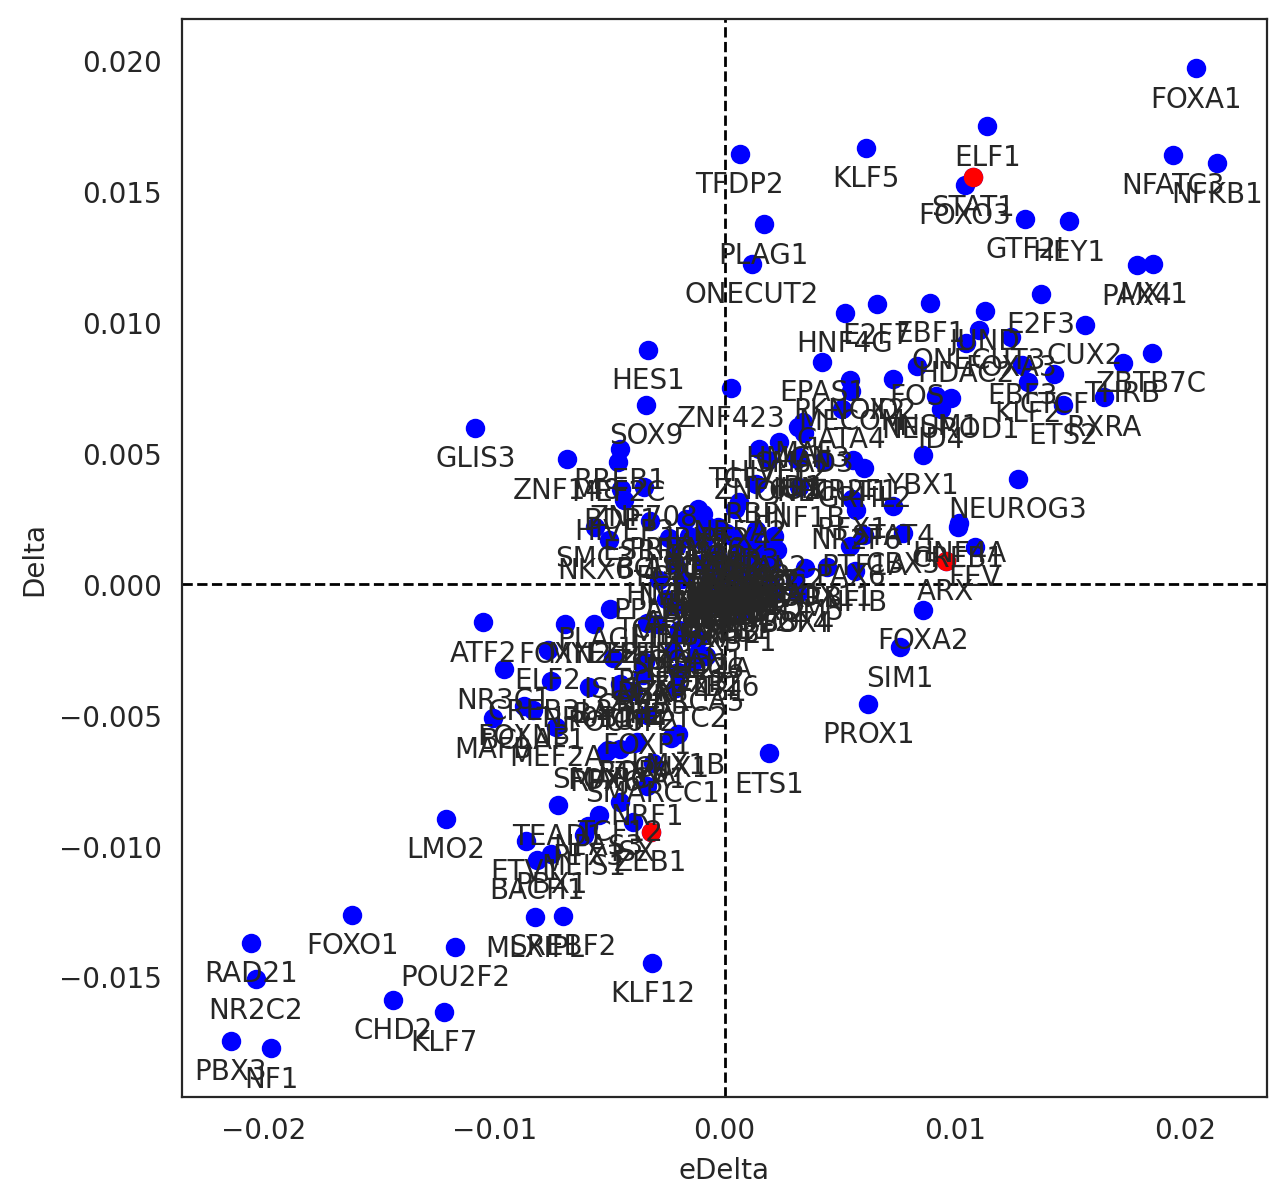

In [17]:
#Full cuadrants
import pandas as pd
import matplotlib.pyplot as plt

# Create the figure with desired size
plt.figure(figsize=(7, 7))

# Assuming df is your existing DataFrame
# df = pd.read_csv('your_dataframe.csv')

# Create a pivot table
pivot_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Filter
filtered_data = pivot_table

# Plot blue points
plt.scatter(filtered_data['eDelta'], filtered_data['Delta'], color='blue')

# Highlight ZEB1 in red
for gene in ['STAT1','ARX','ZEB1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['eDelta'][gene],
                    pivot_table['Delta'][gene],
                    color='red')

        
# Label all genes in filtered_data
for gene in filtered_data.index:
    plt.annotate(
        gene,
        (filtered_data.loc[gene, 'eDelta'], filtered_data.loc[gene, 'Delta']),
        xytext=(0, -6),
        textcoords='offset points',
        ha='center',
        va='top',
        fontsize=10  # reduce if too crowded
    )

# Axes and lines
plt.xlabel('eDelta')
plt.ylabel('Delta')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Save at 600 dpi
plt.savefig(
    "outputs/celloracle_figures/DT_Subset_Delta/PS_scatter_eDelta_vs_Delta_all_quadrants.png",
    dpi=600,
    bbox_inches="tight"  # trims extra whitespace
)

plt.show()

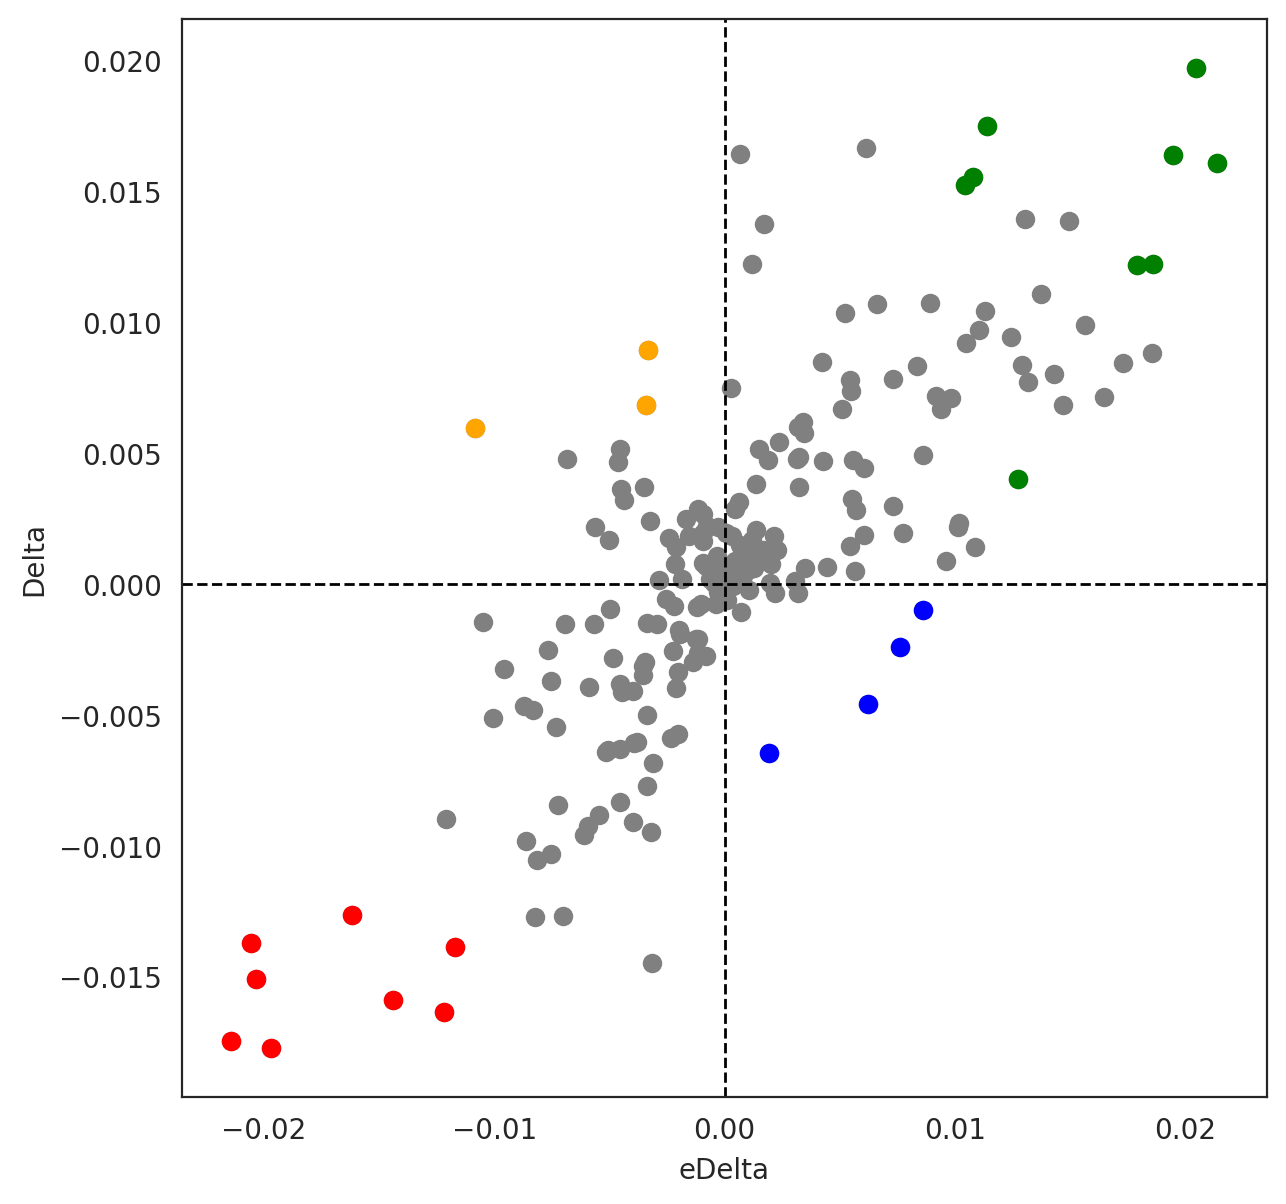

In [20]:
# Create the figure with desired size
plt.figure(figsize=(7, 7))

# Assuming df is your existing DataFrame
# df = pd.read_csv('your_dataframe.csv')

# Create a pivot table
pivot_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Filter
filtered_data = pivot_table

# Plot blue points
plt.scatter(filtered_data['eDelta'], filtered_data['Delta'], color='gray')

# Highlight in green 1
for gene in ['FOXA1','NFATC3','NFKB1','STAT1','PAX4','NEUROG3','MXI1','FOXO3','ELF1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['eDelta'][gene],
                    pivot_table['Delta'][gene],
                    color='green')

# Highlight in orange 2
for gene in ['GLIS3', 'SOX9', 'HES1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['eDelta'][gene],
                    pivot_table['Delta'][gene],
                    color='orange')
        
# Highlight in red 3
for gene in ['NF1','RAD21','PBX3','NR2C2','FOXO1','CHD2','KLF7','POU2F2']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['eDelta'][gene],
                    pivot_table['Delta'][gene],
                    color='red')

# Highlight in blue 4
for gene in ['PROX1', 'SIM1', 'FOXA2','ETS1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['eDelta'][gene],
                    pivot_table['Delta'][gene],
                    color='blue')
        
        
# Axes and lines
plt.xlabel('eDelta')
plt.ylabel('Delta')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Save at 600 dpi
plt.savefig(
    "outputs/celloracle_figures/DT_Subset_Delta/PS_scatter_eDelta_vs_Delta_all_quadrants_NOnametags.png",
    dpi=600,
    bbox_inches="tight"  # trims extra whitespace
)

plt.show()

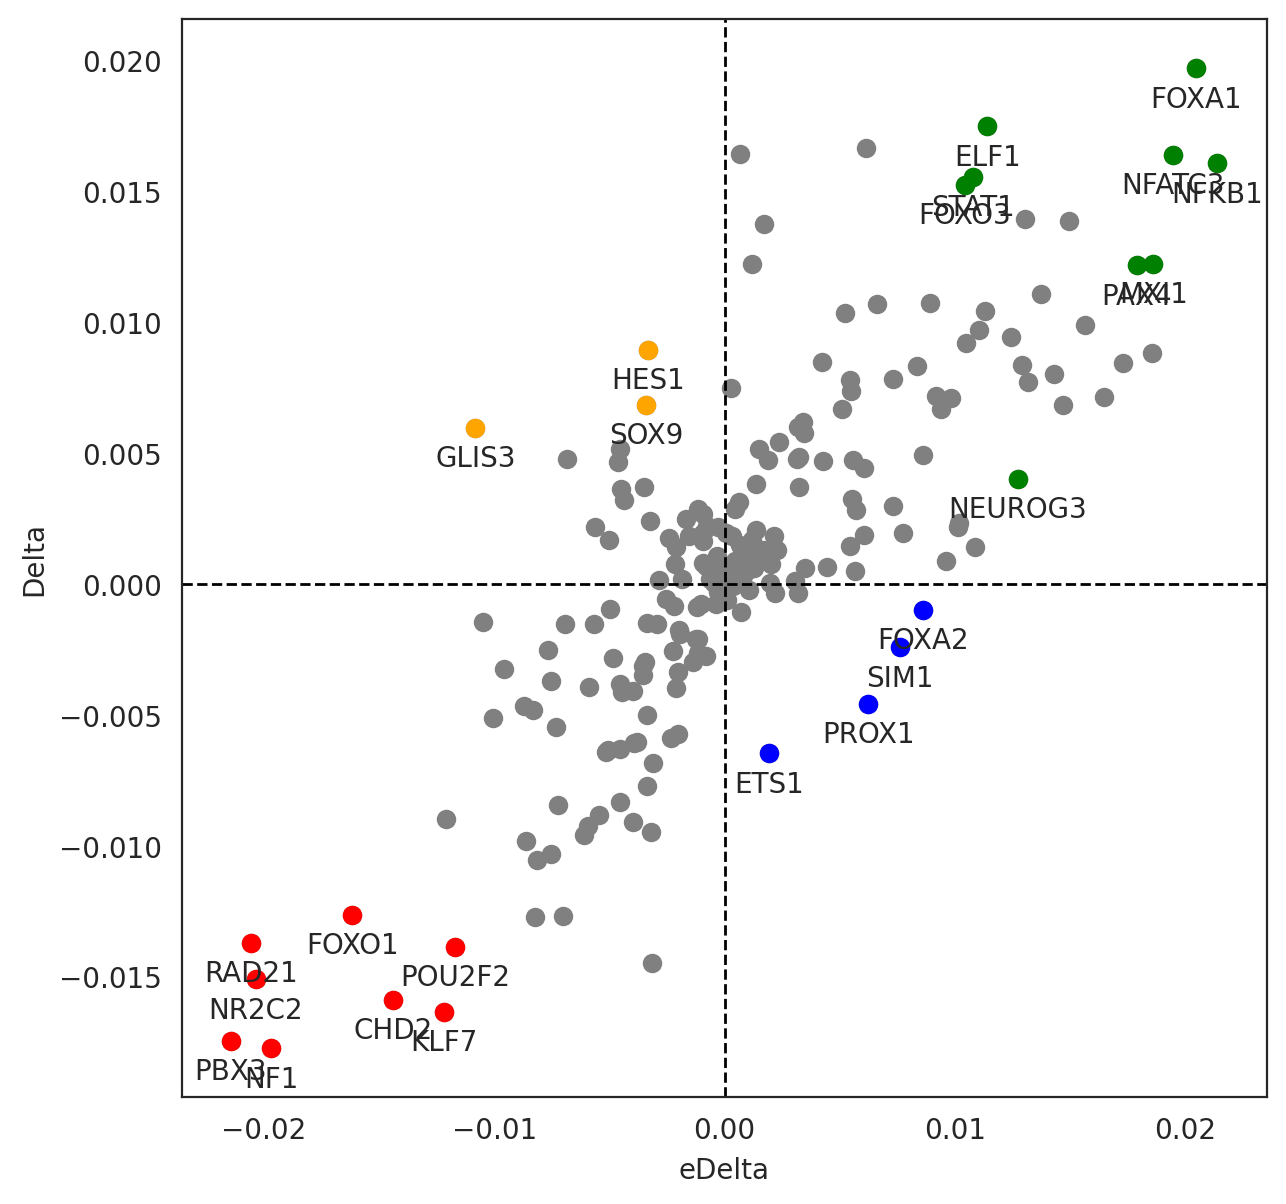

In [21]:
# Create the figure with desired size
plt.figure(figsize=(7, 7))

# Assuming df is your existing DataFrame
# df = pd.read_csv('your_dataframe.csv')

# Create a pivot table
pivot_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Filter
filtered_data = pivot_table

# Plot blue points
plt.scatter(filtered_data['eDelta'], filtered_data['Delta'], color='gray')

# Highlight in green 1
for gene in ['FOXA1','NFATC3','NFKB1','STAT1','PAX4','NEUROG3','MXI1','FOXO3','ELF1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['eDelta'][gene],
                    pivot_table['Delta'][gene],
                    color='green')

# Highlight in orange 2
for gene in ['GLIS3', 'SOX9', 'HES1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['eDelta'][gene],
                    pivot_table['Delta'][gene],
                    color='orange')
        
# Highlight in red 3
for gene in ['NF1','RAD21','PBX3','NR2C2','FOXO1','CHD2','KLF7','POU2F2']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['eDelta'][gene],
                    pivot_table['Delta'][gene],
                    color='red')

# Highlight in blue 4
for gene in ['PROX1', 'SIM1', 'FOXA2','ETS1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['eDelta'][gene],
                    pivot_table['Delta'][gene],
                    color='blue')

# Label only ZEB1 below the dots NAMETAGS
for gene in filtered_data.index:
    if gene in [
        'FOXA1','NFATC3','NFKB1','STAT1','PAX4','NEUROG3','MXI1','FOXO3','ELF1',
        'GLIS3', 'SOX9', 'HES1',
        'NF1','RAD21','PBX3','NR2C2','FOXO1','CHD2','KLF7','POU2F2',
        'PROX1', 'SIM1', 'FOXA2','ETS1'
               ]:
        plt.annotate(
            gene,
            (filtered_data.loc[gene, 'eDelta'], filtered_data.loc[gene, 'Delta']),
            xytext=(0, -6),
            textcoords='offset points',
            ha='center',
            va='top'
        )
        
        
# Axes and lines
plt.xlabel('eDelta')
plt.ylabel('Delta')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Save at 600 dpi
plt.savefig(
    "outputs/celloracle_figures/DT_Subset_Delta/PS_scatter_eDelta_vs_Delta_all_quadrants_Nametags.png",
    dpi=600,
    bbox_inches="tight"  # trims extra whitespace
)

plt.show()

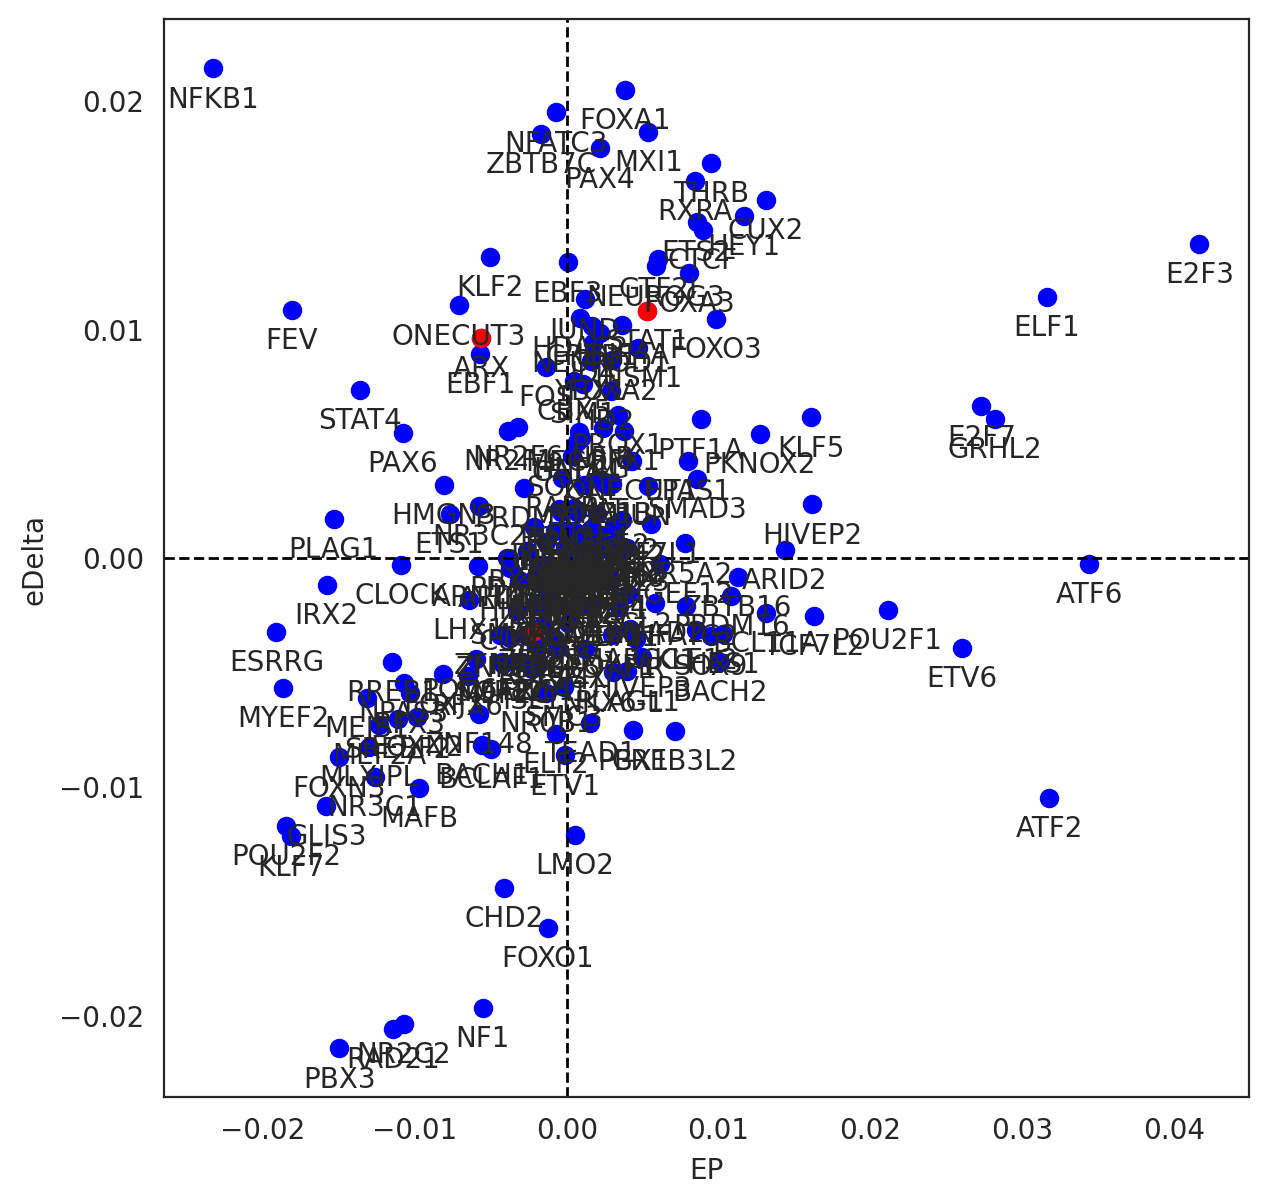

In [29]:
#Full cuadrants
import pandas as pd
import matplotlib.pyplot as plt

# Create the figure with desired size
plt.figure(figsize=(7, 7))

# Assuming df is your existing DataFrame
# df = pd.read_csv('your_dataframe.csv')

# Create a pivot table
pivot_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Filter
filtered_data = pivot_table

# Plot blue points
plt.scatter(filtered_data['EP'], filtered_data['eDelta'], color='blue')

# Highlight ZEB1 in red
for gene in ['STAT1','ARX','ZEB1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['EP'][gene],
                    pivot_table['eDelta'][gene],
                    color='red')

        
# Label all genes in filtered_data
for gene in filtered_data.index:
    plt.annotate(
        gene,
        (filtered_data.loc[gene, 'EP'], filtered_data.loc[gene, 'eDelta']),
        xytext=(0, -6),
        textcoords='offset points',
        ha='center',
        va='top',
        fontsize=10  # reduce if too crowded
    )

# Axes and lines
plt.xlabel('EP')
plt.ylabel('eDelta')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Save at 600 dpi
plt.savefig(
    "outputs/celloracle_figures/DT_Subset_Delta/PS_scatter_EP_vs_eDelta_all_quadrants.png",
    dpi=600,
    bbox_inches="tight"  # trims extra whitespace
)

plt.show()

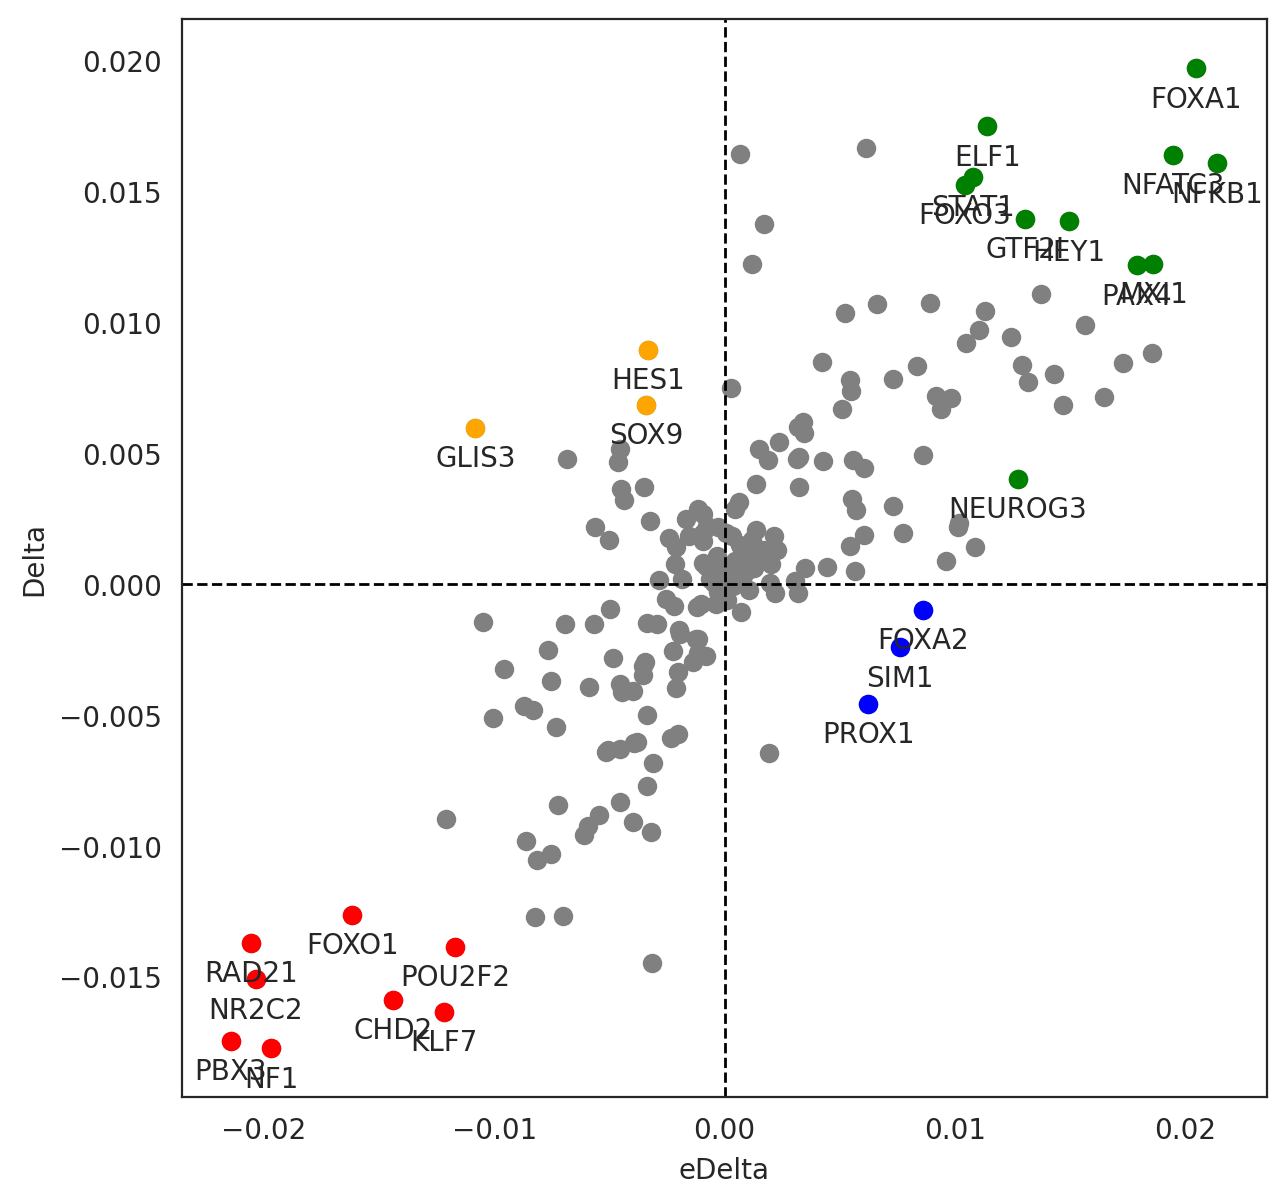

In [27]:
# Create the figure with desired size
plt.figure(figsize=(7, 7))

# Assuming df is your existing DataFrame
# df = pd.read_csv('your_dataframe.csv')

# Create a pivot table
pivot_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Filter
filtered_data = pivot_table

# Plot blue points
plt.scatter(filtered_data['EP'], filtered_data['eDelta'], color='gray')

# Highlight in green 1
for gene in ['E2F3','ELF1','E2F7','GRHL2','FOXA1','PAX4','MXI1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['EP'][gene],
                    pivot_table['eDelta'][gene],
                    color='green')

# Highlight in orange 2
for gene in ['NFKB1', 'FEV', 'NFATC3','ZBTB7C']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['EP'][gene],
                    pivot_table['eDelta'][gene],
                    color='orange')
        
# Highlight in red 3
for gene in ['PBX3','RAD21','NR2C2','FOXO1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['EP'][gene],
                    pivot_table['eDelta'][gene],
                    color='red')

# Highlight in blue 4
for gene in ['ETV6','ATF6','ATF2']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['EP'][gene],
                    pivot_table['eDelta'][gene],
                    color='blue')

# Label only ZEB1 below the dots NAMETAGS
for gene in filtered_data.index:
    if gene in [
        'FOXA1','NFATC3','NFKB1','ELF1','STAT1','PAX4','NEUROG3','MXI1','FOXO3','HEY1','GTF2I',
        'GLIS3', 'SOX9', 'HES1',
        'NF1','RAD21','PBX3','NR2C2','FOXO1','CHD2','KLF7','POU2F2',
        'PROX1', 'SIM1', 'FOXA2'
               ]:
        plt.annotate(
            gene,
            (filtered_data.loc[gene, 'EP'], filtered_data.loc[gene, 'eDelta']),
            xytext=(0, -6),
            textcoords='offset points',
            ha='center',
            va='top'
        )
        
        
# Axes and lines
plt.xlabel('EP')
plt.ylabel('eDelta')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Save at 600 dpi
plt.savefig(
    "outputs/celloracle_figures/DT_Subset_Delta/PS_scatter_EP_vs_eDelta_all_quadrants_Nametags.png",
    dpi=600,
    bbox_inches="tight"  # trims extra whitespace
)

plt.show()

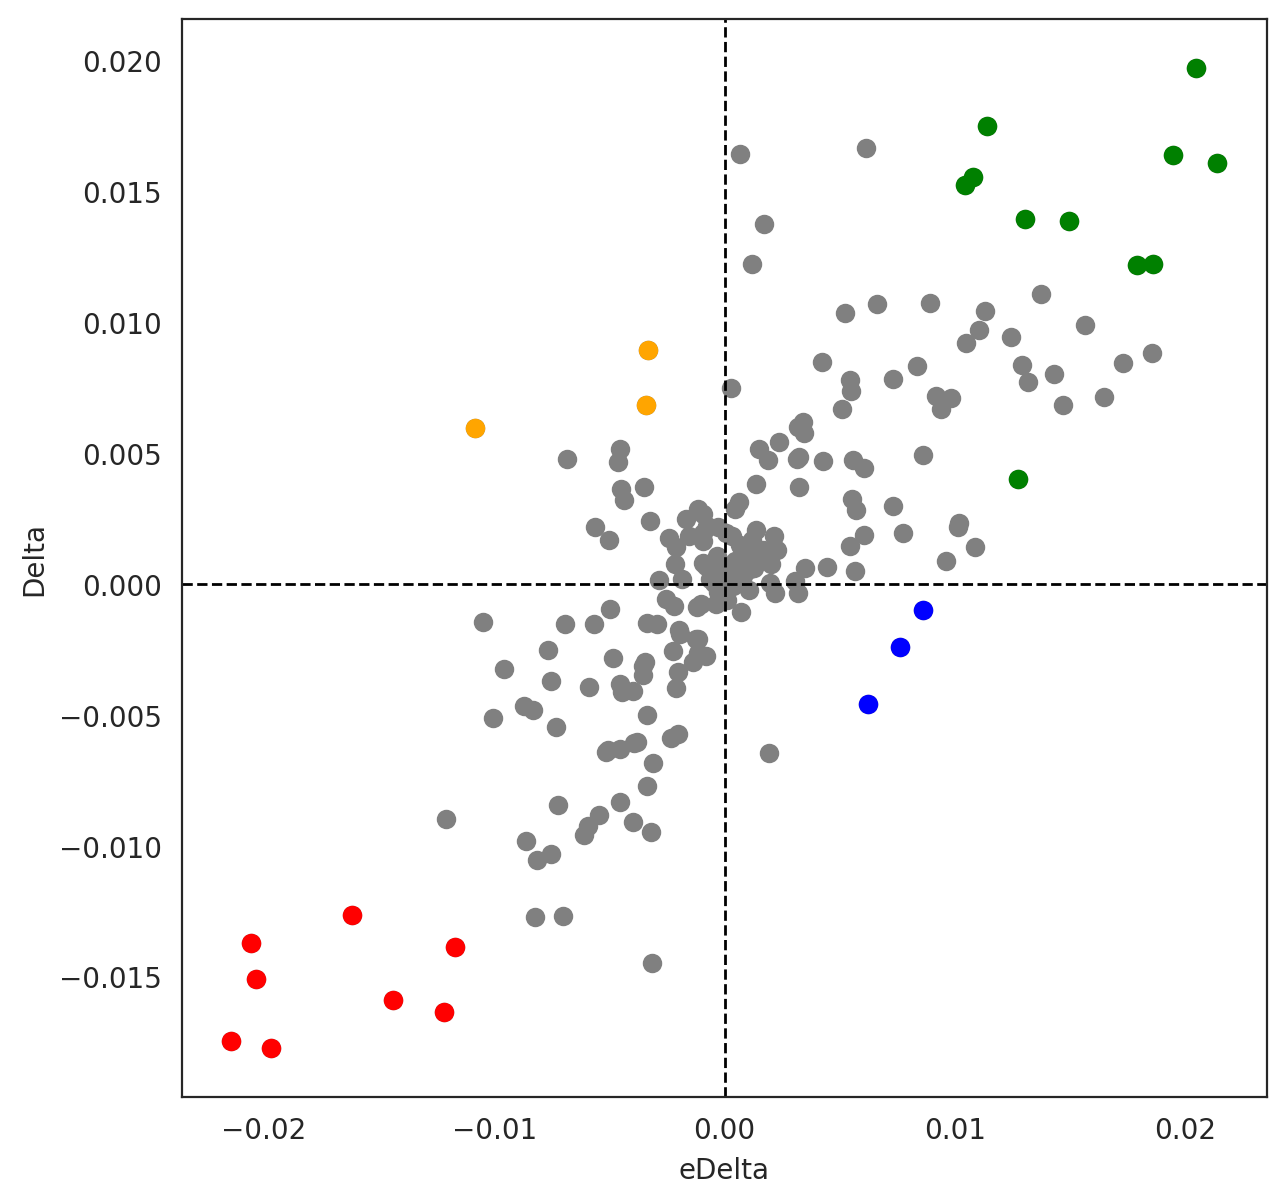

In [28]:
# Create the figure with desired size
plt.figure(figsize=(7, 7))

# Assuming df is your existing DataFrame
# df = pd.read_csv('your_dataframe.csv')

# Create a pivot table
pivot_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Filter
filtered_data = pivot_table

# Plot blue points
plt.scatter(filtered_data['EP'], filtered_data['eDelta'], color='gray')

# Highlight in green 1
for gene in ['FOXA1','NFATC3','NFKB1','ELF1','STAT1','PAX4','NEUROG3','MXI1','FOXO3','HEY1','GTF2I']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['EP'][gene],
                    pivot_table['eDelta'][gene],
                    color='green')

# Highlight in orange 2
for gene in ['GLIS3', 'SOX9', 'HES1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['EP'][gene],
                    pivot_table['eDelta'][gene],
                    color='orange')
        
# Highlight in red 3
for gene in ['NF1','RAD21','PBX3','NR2C2','FOXO1','CHD2','KLF7','POU2F2']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['EP'][gene],
                    pivot_table['eDelta'][gene],
                    color='red')

# Highlight in blue 4
for gene in ['PROX1', 'SIM1', 'FOXA2']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['EP'][gene],
                    pivot_table['eDelta'][gene],
                    color='blue')
        
        
# Axes and lines
plt.xlabel('EP')
plt.ylabel('eDelta')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Save at 600 dpi
plt.savefig(
    "outputs/celloracle_figures/DT_Subset_Delta/PS_scatter_EP_vs_eDelta_all_quadrants_NOnametags.png",
    dpi=600,
    bbox_inches="tight"  # trims extra whitespace
)

plt.show()

In [96]:
# Como no digo lo que quieren, ahora miran feo. Ya saben que les deseo: - QUE SE MEJOREN by WOS